In [1]:
#imports
from tensorflow.keras.datasets import mnist
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load the Dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Display dataset shapes
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


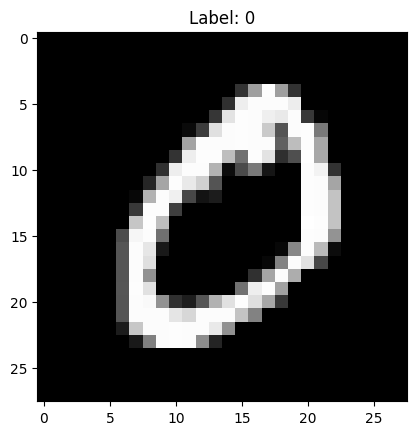

In [3]:
# Basic Data Visualisation
img = x_train[1,:,:]
label = y_train[1]

plt.imshow(img, cmap='gray')
plt.title(f"Label: {label}")
plt.show()

# **Data Preprocessing**
Normalize the data and reshape it for CNN input

In [4]:
# Normalize and reshape
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255
x_test = x_test.reshape(-1, 28, 28, 1).astype('float') / 255

# one-hot encode labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# **Model Building**
Build a CNN model using Keras Sequential API

In [5]:
model = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),  # Convolution layer -> detects patterns
    MaxPooling2D(pool_size=(2,2)),  # Pooling layer -> reduces spatial dimensions
    Conv2D(64, kernel_size=(3,3), activation='relu'),  # Convolution layer -> detects patterns
    MaxPooling2D(pool_size=(2,2)),  # Pooling layer -> reduces spatial dimensions
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

# **Model Compilation**
compile the model with Adam optimizer and categorical crossentropy loss

In [6]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


#**Model Training**
train the model on the training data

In [7]:
history=model.fit(x_train,y_train,epochs=10,batch_size=128,validation_split=0.2)
#epochs -> Model sees dataset 5 times
# Batch_size=Process 128 images per step
# Validation_split -> Uses 20% of training data for validation

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8452 - loss: 0.5353 - val_accuracy: 0.9796 - val_loss: 0.0729
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9809 - loss: 0.0610 - val_accuracy: 0.9827 - val_loss: 0.0549
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9862 - loss: 0.0421 - val_accuracy: 0.9876 - val_loss: 0.0434
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9917 - loss: 0.0286 - val_accuracy: 0.9875 - val_loss: 0.0451
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9929 - loss: 0.0227 - val_accuracy: 0.9862 - val_loss: 0.0455
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9944 - loss: 0.0186 - val_accuracy: 0.9888 - val_loss: 0.0385
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9960 - loss: 0.0138 - val_accuracy: 0.9894 - val_loss: 0.0387
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9960 - loss: 0.0122 - val_accuracy: 0.

# **Model Evalutaion**
Evaluate the model on the test data

In [8]:
test_loss,test_accuracy=model.evaluate(x_test,y_test)
print(f"Test Accuracy: {test_accuracy}")
print(f"Test Loss:{test_loss}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9852 - loss: 0.0450
Test Accuracy: 0.9894000291824341
Test Loss:0.034920401871204376


# **Prediction**
Make predictions on new data samples.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


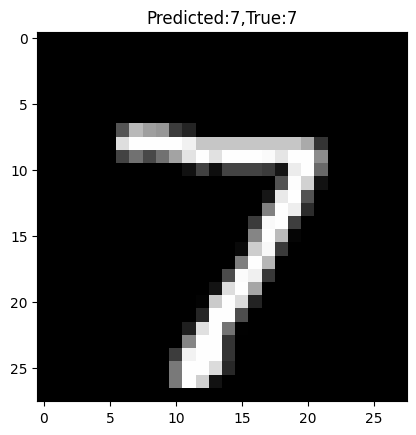

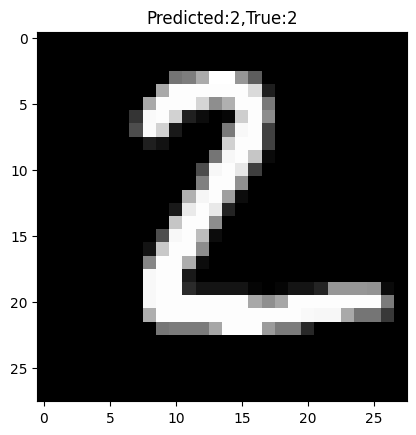

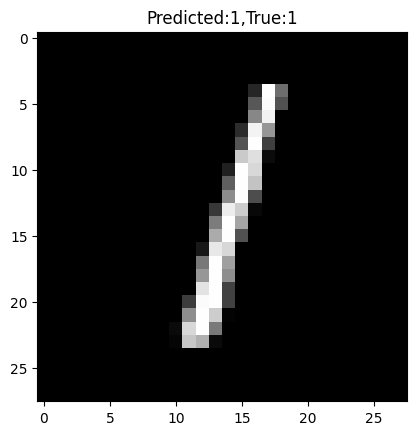

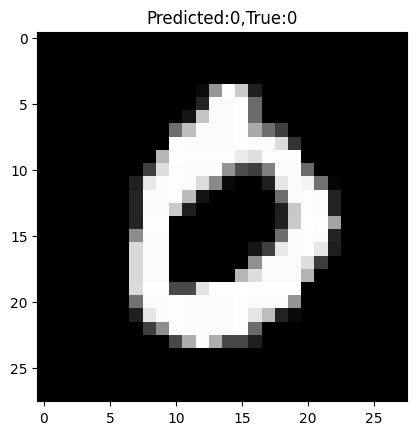

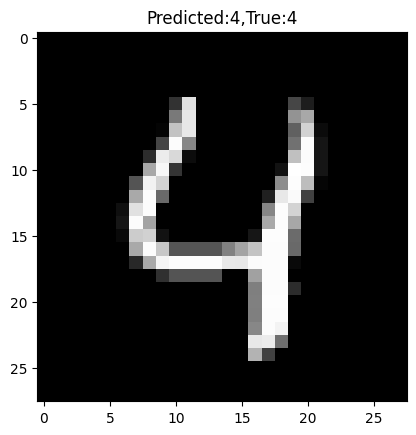

In [9]:
#Predict on the few test samples
predictions=model.predict(x_test)
predicted_classes=np.argmax(predictions,axis=1)
true_classes=np.argmax(y_test,axis=1)

for i in range(5):
  plt.imshow(x_test[i].reshape(28,28),cmap='gray')
  plt.title(f"Predicted:{predicted_classes[i]},True:{true_classes[i]}")
  plt.show()